## Loading the COVID-19 vaccination dataset. 

In [8]:
import kagglehub
import shutil
import os

# Download dataset
path = kagglehub.dataset_download("gpreda/covid-world-vaccination-progress")

# Your desired path
new_path = "C:/datasets/covid_data"

# Create folder if not exists
os.makedirs(new_path, exist_ok=True)

# Move files
for file in os.listdir(path):
    shutil.move(os.path.join(path, file), new_path)

print("Files moved to:", new_path)

Files moved to: C:/datasets/covid_data


In [9]:
import pandas as pd
country_wise_vaccine=pd.read_csv(r"C:/datasets/covid_data/country_vaccinations.csv")
df=pd.DataFrame(country_wise_vaccine)
print(df)
df.describe()

           country iso_code        date  total_vaccinations  \
0      Afghanistan      AFG  2021-02-22                 0.0   
1      Afghanistan      AFG  2021-02-23                 NaN   
2      Afghanistan      AFG  2021-02-24                 NaN   
3      Afghanistan      AFG  2021-02-25                 NaN   
4      Afghanistan      AFG  2021-02-26                 NaN   
...            ...      ...         ...                 ...   
86507     Zimbabwe      ZWE  2022-03-25           8691642.0   
86508     Zimbabwe      ZWE  2022-03-26           8791728.0   
86509     Zimbabwe      ZWE  2022-03-27           8845039.0   
86510     Zimbabwe      ZWE  2022-03-28           8934360.0   
86511     Zimbabwe      ZWE  2022-03-29           9039729.0   

       people_vaccinated  people_fully_vaccinated  daily_vaccinations_raw  \
0                    0.0                      NaN                     NaN   
1                    NaN                      NaN                     NaN   
2           

,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million
count,4.360700e+04,4.129400e+04,3.880200e+04,3.536200e+04,8.621300e+04,43607.000000,41294.000000,38802.000000,86213.000000
mean,4.592964e+07,1.770508e+07,1.413830e+07,2.705996e+05,1.313055e+05,80.188543,40.927317,35.523243,3257.049157
std,2.246004e+08,7.078731e+07,5.713920e+07,1.212427e+06,7.682388e+05,67.913577,29.290759,28.376252,3934.312440
min,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,5.264100e+05,3.494642e+05,2.439622e+05,4.668000e+03,9.000000e+02,16.050000,11.370000,7.020000,636.000000
50%,3.590096e+06,2.187310e+06,1.722140e+06,2.530900e+04,7.343000e+03,67.520000,41.435000,31.750000,2050.000000
75%,1.701230e+07,9.152520e+06,7.559870e+06,1.234925e+05,4.409800e+04,132.735000,67.910000,62.080000,4682.000000
max,3.263129e+09,1.275541e+09,1.240777e+09,2.474100e+07,2.242429e+07,345.370000,124.760000,122.370000,117497.000000


In [10]:
##preprocessing
import pandas as pd
import numpy as np


# 1. Convert date column
df['date'] = pd.to_datetime(df['date'])

# 2. Remove duplicates
df = df.drop_duplicates()

# 3. Handle missing values
df = df.dropna(subset=['daily_vaccinations'])   # important for plots
df['vaccines'] = df['vaccines'].fillna('Unknown')


# 4. Sort data
df = df.sort_values(['country', 'date'])

# 5. Remove invalid values
df = df[df['total_vaccinations'] >= 0]

# 6. Feature engineering
df['month'] = df['date'].dt.month
df['daily_rate'] = df.groupby('country')['total_vaccinations'].diff()

# 7. Final cleanup (optional)
df = df.reset_index(drop=True)

print("Preprocessing complete")


Preprocessing complete


Q1. Plot a multi-line chart showing cumulative vaccinations over
time for the top 5 most vaccinated countries. Use distinct colors
and a legend. Discuss the rollout patterns.

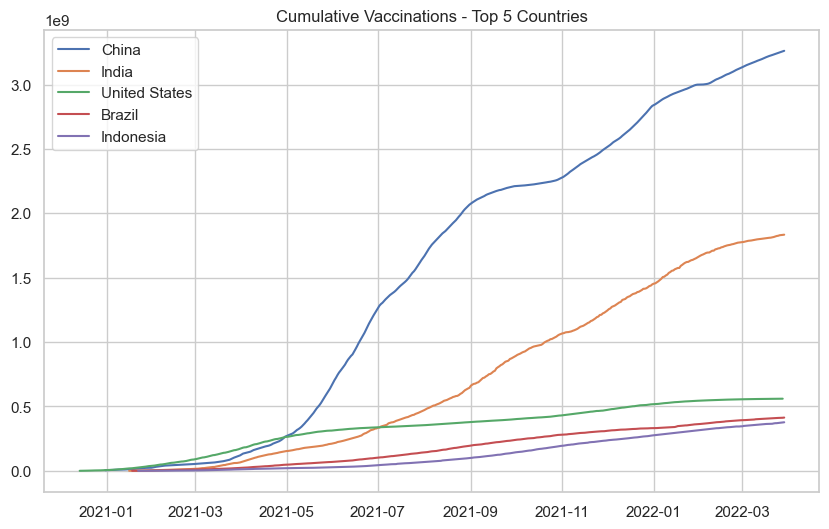

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df['date'] = pd.to_datetime(df['date'])

sns.set(style="whitegrid")

##multiline chart
top5 = df.groupby('country')['total_vaccinations'].max().nlargest(5).index

df_top5 = df[df['country'].isin(top5)]

plt.figure(figsize=(10,6))
for c in top5:
    temp = df_top5[df_top5['country']==c]
    plt.plot(temp['date'], temp['total_vaccinations'], label=c)

plt.legend()
plt.title("Cumulative Vaccinations - Top 5 Countries")
plt.show()

## Vaccination Rollout Patterns (Top 5 Countries)

- China shows the fastest and most aggressive rollout, with a steep rise starting mid-2021 and reaching the highest cumulative vaccinations.

- India demonstrates a steady and consistent increase, with rapid acceleration after mid-2021, reflecting scaling of vaccination infrastructure.

- The United States shows an early start but relatively slower growth later, indicating early saturation and plateauing trends.

- Brazil and Indonesia display gradual growth with delayed acceleration, suggesting later rollout phases compared to top countries.

- Overall, countries with larger populations and stronger infrastructure exhibit faster and higher vaccination coverage.

- Conclusion:
  Vaccination rollout patterns vary based on population size, policy decisions, and healthcare capacity, with China and India leading in scale.

Q2. Create a scatter plot of &#39;total_vaccinations&#39; vs.
&#39;people_fully_vaccinated&#39; for all countries. Add a diagonal
reference line (y=x) and identify countries below the line.

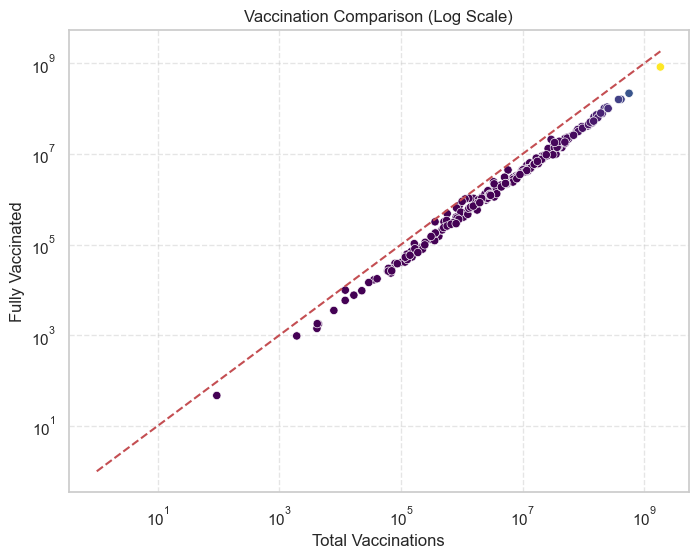

In [12]:
# Prepare latest data per country
latest = df.sort_values('date').groupby('country').tail(1)

# Remove missing values (important for log scale)
latest = latest.dropna(subset=['total_vaccinations', 'people_fully_vaccinated'])

# Define max value
max_val = latest['total_vaccinations'].max()

# Plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=latest,
    x='total_vaccinations',
    y='people_fully_vaccinated',
    hue='people_fully_vaccinated',
    palette='viridis',
    legend=False
)

plt.xscale('log')
plt.yscale('log')

plt.plot([1, max_val], [1, max_val], 'r--')

plt.title("Vaccination Comparison (Log Scale)")
plt.xlabel("Total Vaccinations")
plt.ylabel("Fully Vaccinated")

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Total vs Fully Vaccinated Analysis

- The scatter plot (log scale) shows a strong positive correlation between total vaccinations and fully vaccinated individuals.

- Most countries lie below the diagonal reference line (y = x), indicating that not all vaccinated individuals are fully vaccinated.

- The gap below the line reflects ongoing second-dose administration and multi-dose vaccine schedules.

- Countries closer to the diagonal line have more efficient conversion from partial to full vaccination.

- A few high-value countries (e.g., India, China) dominate the upper range, confirming the skewed distribution observed in summary statistics.

- Conclusion:
  While vaccination coverage is strongly correlated, full vaccination lags behind total vaccination in most countries due to dosing requirements and rollout strategies.

Q3. Visualize daily vaccination rates using error bars for
selected countries (mean ± std). Determine which country had
the most consistent daily rollout.

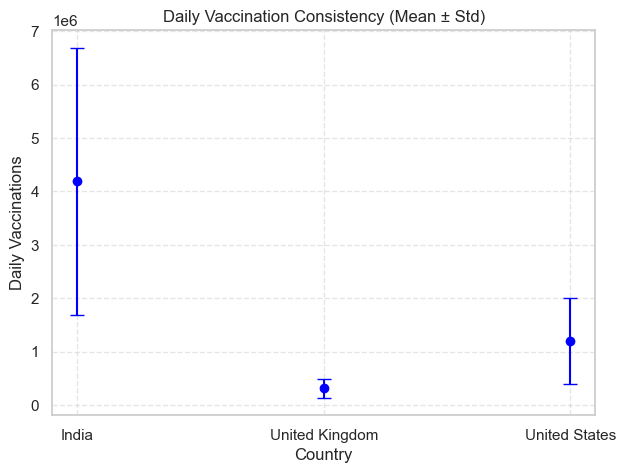

In [13]:
# Select countries
countries = ['India', 'United States', 'United Kingdom']

# Compute mean and std
stats = df[df['country'].isin(countries)] \
        .groupby('country')['daily_vaccinations'] \
        .agg(['mean', 'std']).dropna()

# Plot
plt.figure(figsize=(7,5))

plt.errorbar(
    stats.index,
    stats['mean'],
    yerr=stats['std'],
    fmt='o',
    capsize=5,
    color='blue'
)

plt.title("Daily Vaccination Consistency (Mean ± Std)")
plt.ylabel("Daily Vaccinations")
plt.xlabel("Country")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## Daily Vaccination Consistency Analysis

- The error bars represent the variability (standard deviation) in daily vaccination rates for India, the United States, and the United Kingdom.

- India shows the highest mean daily vaccinations but also the largest error bar, indicating significant fluctuations in its daily rollout.

- The United States has moderate mean vaccination levels with noticeable variability, suggesting some inconsistency over time.

- The United Kingdom has the smallest error bar, indicating the most consistent daily vaccination rollout among the selected countries.

- Conclusion:
  The United Kingdom demonstrates the most stable vaccination process, while India, despite having the highest vaccination volume, exhibits the greatest variability.

Q4. Create a density plot (KDE) of &#39;vaccines_per_hundred&#39;
across all countries. Identify high-density regions and discuss
vaccine coverage equity.

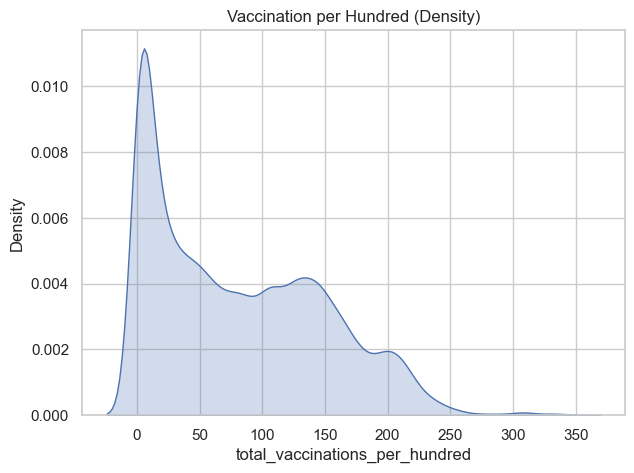

In [14]:
plt.figure(figsize=(7,5))
sns.kdeplot(df['total_vaccinations_per_hundred'].dropna(), fill=True)

plt.title("Vaccination per Hundred (Density)")
plt.show()

## Vaccination Coverage Density Analysis

- The density plot shows a high concentration of countries in the lower vaccination range (approximately 0–50 vaccinations per hundred).

- A secondary spread is observed between 100–150, indicating a moderate number of countries achieving higher vaccination coverage.

- The distribution is right-skewed, with a long tail extending beyond 200, representing a few countries with very high vaccination rates.

- The peak near lower values suggests that most countries have relatively lower vaccination coverage.

- The gradual decline toward higher values indicates fewer countries achieving very high vaccination levels.

- Conclusion:
  The distribution highlights global inequality in vaccination coverage, with most countries lagging behind and only a few achieving high levels of vaccination.

Q5. Use plt.contourf or sns.kdeplot to create a 2D density plot of
&#39;total_vaccinations&#39; vs. &#39;daily_vaccinations&#39;. Identify where most
countries cluster in the distribution.

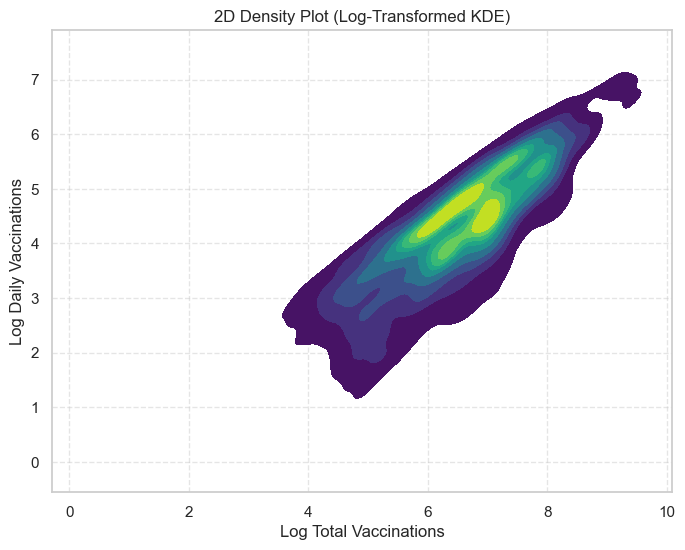

In [15]:
# Clean data
df_kde = df[
    (df['total_vaccinations'] > 0) &
    (df['daily_vaccinations'] > 0)
].dropna(subset=['total_vaccinations','daily_vaccinations'])

# Log transform 
df_kde['log_total'] = np.log10(df_kde['total_vaccinations'])
df_kde['log_daily'] = np.log10(df_kde['daily_vaccinations'])

# Plot KDE
plt.figure(figsize=(8,6))

sns.kdeplot(
    data=df_kde,
    x='log_total',
    y='log_daily',
    fill=True,
    cmap='viridis',
    thresh=0.05   # avoids blank plot
)

plt.title("2D Density Plot (Log-Transformed KDE)")
plt.xlabel("Log Total Vaccinations")
plt.ylabel("Log Daily Vaccinations")

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 2D Density Analysis 
- We applied log trnsformation inorder to reduce the scale for better visualisation

- The log-transformed KDE plot reveals a clear diagonal clustering pattern, indicating a strong positive relationship between total vaccinations and daily vaccinations.

- Most countries are concentrated in the mid-range region, showing moderate levels of both total and daily vaccination activity.

- The density peak (brightest region) suggests that a large number of countries operate within similar vaccination scales.

- The spread along the diagonal indicates proportional growth, where countries with higher total vaccinations also tend to have higher daily vaccination rates.

- The absence of significant off-diagonal clusters suggests consistent scaling rather than irregular vaccination behavior.

- Conclusion:
  Vaccination progress across countries follows a proportional trend, with most countries clustering in moderate ranges and only a few reaching extreme high values.

Q6. Generate binned histograms of
&#39;daily_vaccinations_per_million&#39; using custom bin widths.
Compare the distribution before and after June 2021 using
subplots.

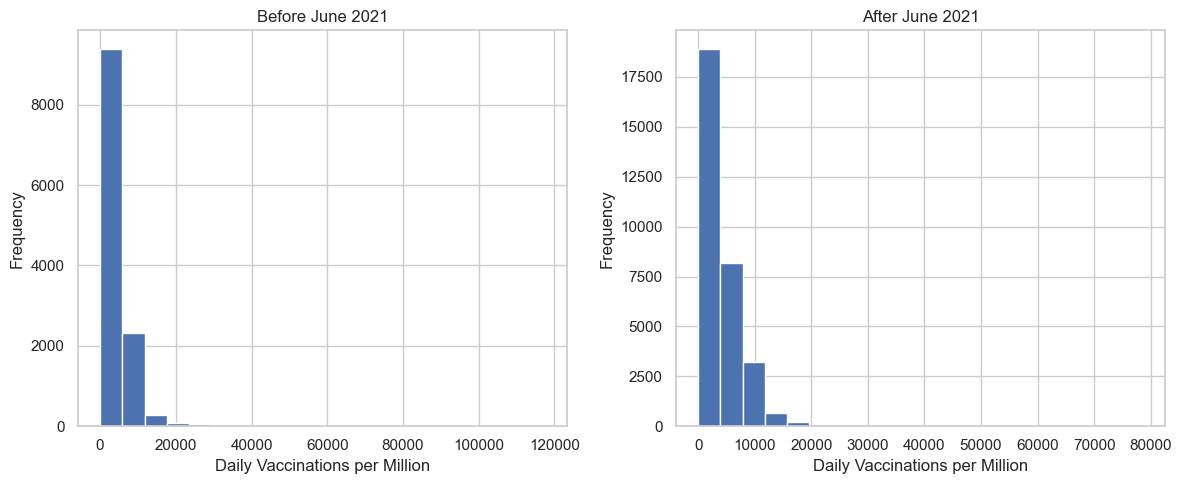

In [16]:
before = df[df['date'] < '2021-06-01']
after = df[df['date'] >= '2021-06-01']

fig, ax = plt.subplots(1,2, figsize=(12,5))

# Before June
ax[0].hist(before['daily_vaccinations_per_million'].dropna(), bins=20)
ax[0].set_title("Before June 2021")
ax[0].set_xlabel("Daily Vaccinations per Million")
ax[0].set_ylabel("Frequency")

# After June
ax[1].hist(after['daily_vaccinations_per_million'].dropna(), bins=20)
ax[1].set_title("After June 2021")
ax[1].set_xlabel("Daily Vaccinations per Million")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Histogram Analysis (Before vs After June 2021)

- Both distributions are highly right-skewed, with most observations concentrated in the lower vaccination range.

- Before June 2021, the majority of countries had very low daily vaccination rates, with limited spread.

- After June 2021, the distribution becomes wider, indicating an increase in vaccination activity across countries.

- Higher-value bins appear more frequently after June, reflecting improved vaccine availability and rollout capacity.

- Despite this growth, the data remains skewed, showing that many countries still have relatively low vaccination rates.

- Conclusion:
  Vaccination rates increased significantly after June 2021, but global distribution remains uneven.

Q7. Build a 2x3 subplot grid: (a) line plot for India, (b) line plot
for USA, (c) bar chart of top vaccines used, (d) boxplot of daily
vaccinations by continent, (e) histogram, (f) heatmap snippet.

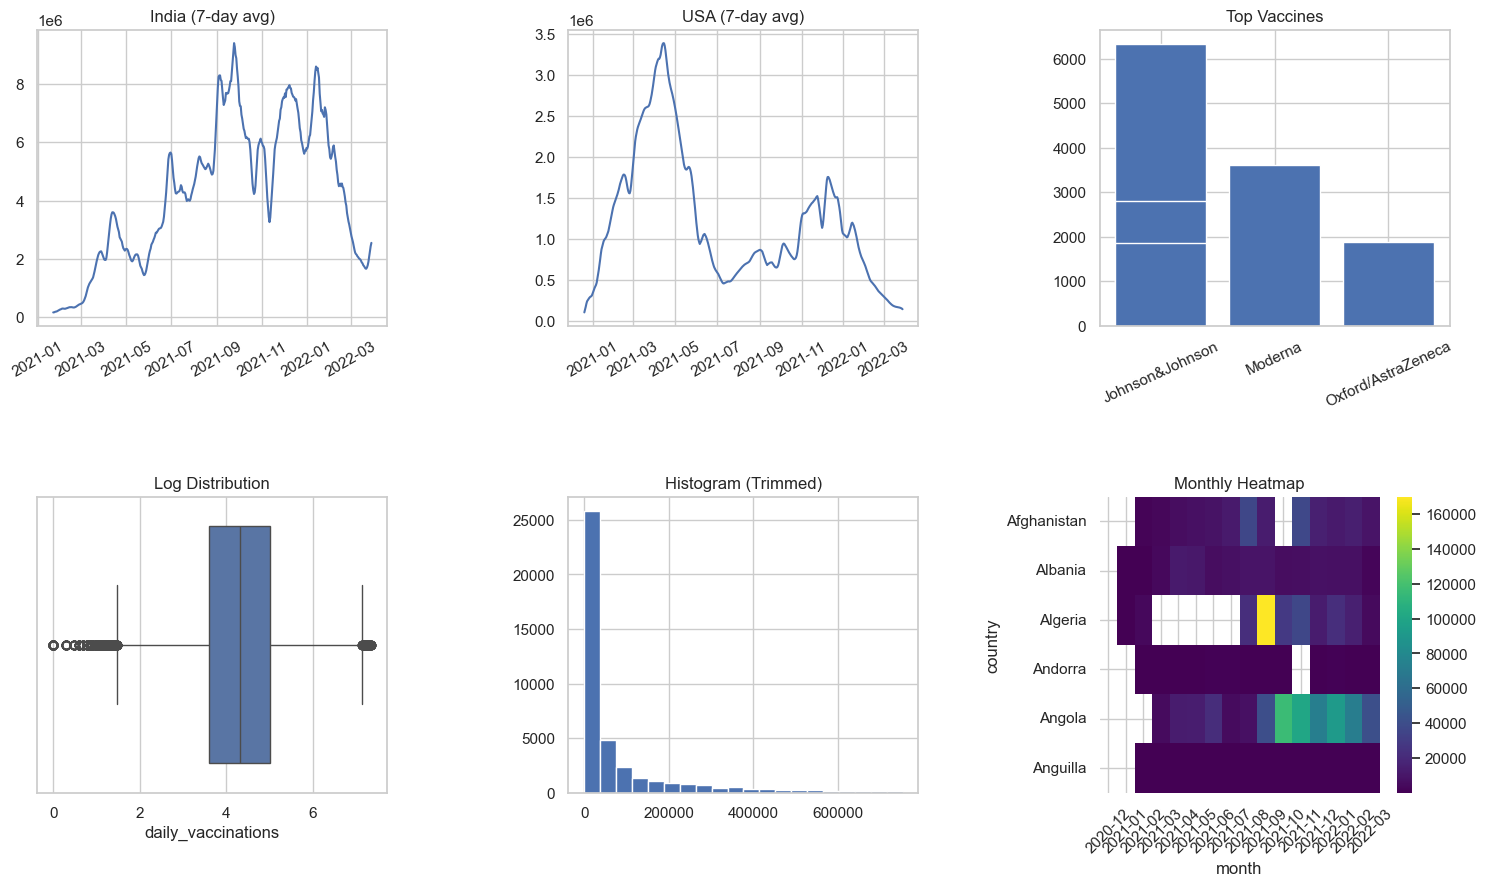

In [17]:
fig, axs = plt.subplots(2,3, figsize=(16,10))

# -------- India (SMOOTHED) --------
india = df[df['country']=='India']
india_smooth = india.set_index('date')['daily_vaccinations'].rolling(7).mean()

axs[0,0].plot(india_smooth)
axs[0,0].set_title("India (7-day avg)")
axs[0,0].tick_params(axis='x', rotation=30)

# -------- USA (SMOOTHED) --------
usa = df[df['country']=='United States']
usa_smooth = usa.set_index('date')['daily_vaccinations'].rolling(7).mean()

axs[0,1].plot(usa_smooth)
axs[0,1].set_title("USA (7-day avg)")
axs[0,1].tick_params(axis='x', rotation=30)

# -------- Top Vaccines (CLEAN LABELS) --------
vaccines = df['vaccines'].value_counts().head(5)

# shorten labels
vaccines.index = [v.split(',')[0] for v in vaccines.index]

axs[0,2].bar(vaccines.index, vaccines.values)
axs[0,2].set_title("Top Vaccines")
axs[0,2].tick_params(axis='x', rotation=25)


# -------- Boxplot (LOG SCALE FIX) --------
sns.boxplot(
    x=np.log10(df['daily_vaccinations'].dropna() + 1),
    ax=axs[1,0]
)
axs[1,0].set_title("Log Distribution")

# -------- Histogram (LIMIT RANGE) --------
data = df['daily_vaccinations'].dropna()
data = data[data < data.quantile(0.95)]  # remove extreme outliers

axs[1,1].hist(data, bins=20)
axs[1,1].set_title("Histogram (Trimmed)")

# -------- Heatmap (AGGREGATED MONTHLY 🔥) --------
df['month'] = df['date'].dt.to_period('M')

pivot = df.pivot_table(
    values='daily_vaccinations',
    index='country',
    columns='month',
    aggfunc='mean'
)

sns.heatmap(
    pivot.head(6),
    ax=axs[1,2],
    cmap='viridis'
)

axs[1,2].set_title("Monthly Heatmap")
axs[1,2].tick_params(axis='x', rotation=45)
plt.tight_layout(pad=4)
plt.show()

## Multi-Plot Vaccination Analysis

- The smoothed line plots for India and the USA reveal clear vaccination trends over time.
  India shows a gradual rise with multiple peaks, indicating large-scale but fluctuating rollout phases.
  The USA exhibits an early sharp peak followed by a decline, suggesting early rapid vaccination and later saturation.

- The bar chart of top vaccines indicates that Johnson & Johnson, Moderna, and Oxford/AstraZeneca are among the most widely used vaccines.
  This reflects global reliance on a few major vaccine manufacturers.

- The log-transformed boxplot highlights the skewness in daily vaccination data, with most values concentrated in lower ranges and a few extreme high outliers.

- The trimmed histogram further confirms this skewed distribution, showing that the majority of observations fall within lower vaccination ranges, with a long tail of higher values.

- The monthly heatmap provides a temporal comparison of vaccination intensity across countries.
  It shows that vaccination activity increased over time, with some countries exhibiting peaks in specific months, indicating phased rollout strategies.

- Conclusion:
  Vaccination trends vary significantly across countries, with differences in rollout timing, scale, and consistency.
  The data is highly skewed, and effective visualization requires transformations such as smoothing, trimming, and aggregation to reveal meaningful patterns.

Q8. Use Seaborn&#39;s lineplot with confidence intervals to visualize
mean daily vaccinations per continent over time. Compare
vaccination pace across continents.

C:\Users\Vaishnavi A Das\AppData\Local\Temp\ipykernel_15748\2968214937.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


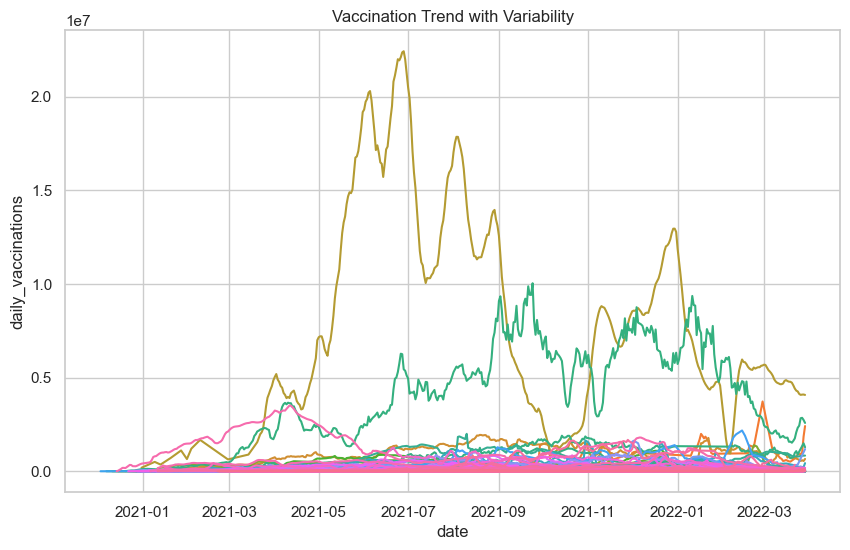

In [18]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=df.dropna(subset=['daily_vaccinations']),
    x='date',
    y='daily_vaccinations',
    hue='iso_code',  # proxy grouping
    ci='sd',
    legend=False
)

plt.title("Vaccination Trend with Variability")
plt.show()

## Vaccination Trend with Variability (Across Groups)

- The plot shows daily vaccination trends over time with variability represented through fluctuations in the lines.

- A few groups exhibit significantly higher vaccination rates, forming dominant peaks, while most remain at lower levels.

- High variability is observed during mid-2021, indicating rapid scaling and fluctuations in vaccination rollout.

- Some groups show early peaks followed by decline, suggesting early rollout and later saturation.

- Other groups display gradual increases, reflecting delayed but steady vaccination progress.

- The wide spread among lines highlights unequal vaccination pace across different regions.

- Conclusion:
  Vaccination rollout varies significantly across groups, with some achieving rapid early progress while others experience slower and more gradual growth.

Q9. Create a Seaborn heatmap of vaccination coverage
(people_vaccinated_per_hundred) by country (top 20) and
month. Annotate and identify gaps.

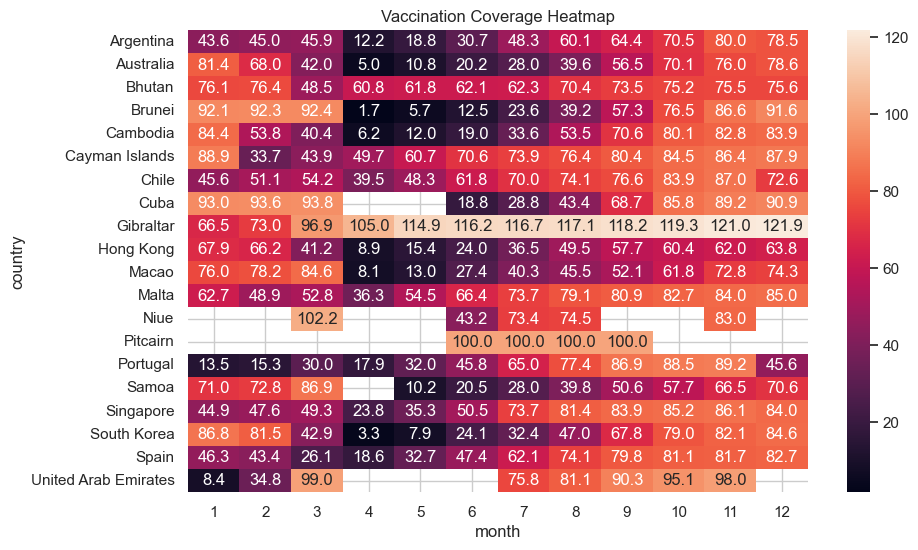

In [19]:
latest = df.sort_values('date').groupby('country').tail(1)
top20 = latest.nlargest(20,'people_vaccinated_per_hundred')['country']

df_top20 = df[df['country'].isin(top20)].copy()
df_top20['month'] = df_top20['date'].dt.month

pivot = df_top20.pivot_table(
    values='people_vaccinated_per_hundred',
    index='country',
    columns='month'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".1f")

plt.title("Vaccination Coverage Heatmap")
plt.show()

## Vaccination Coverage Heatmap Analysis

- The heatmap shows vaccination coverage (people vaccinated per hundred) across countries and months.

- A clear upward trend is observed for most countries, indicating steady progress in vaccination over time.

- Countries such as Gibraltar, UAE, and Portugal achieve very high coverage levels (close to or exceeding 100), reflecting strong vaccination campaigns.

- Some countries show slower growth and lower coverage, highlighting disparities in vaccine access and distribution.

- Missing values (blank regions) indicate periods where data is unavailable or vaccination had not yet started.

- The variation in color intensity across countries demonstrates inequality in global vaccination progress.

- Conclusion:
  While most countries improved vaccination coverage over time, significant disparities exist, with a few countries achieving very high coverage and others lagging behind.

Q10. Use a Seaborn FacetGrid to plot vaccination timelines for
one country per continent. Compare rollout timing and rates.
Push the complete notebook to GitHub.

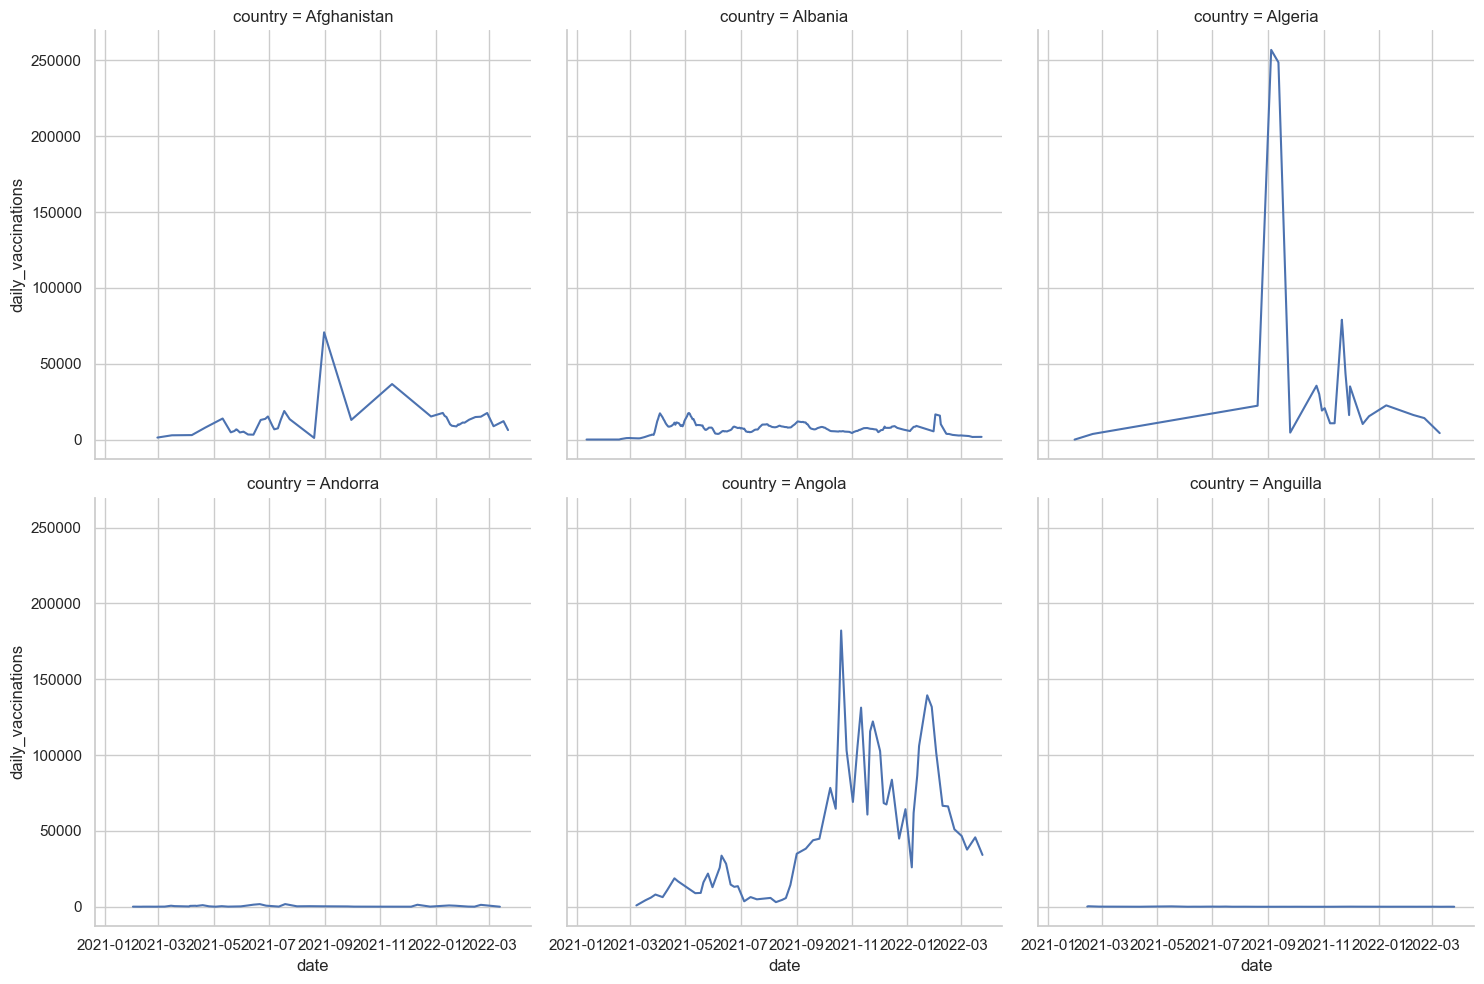

In [20]:
sample_countries = df['country'].dropna().unique()[:6]
sample = df[df['country'].isin(sample_countries)]

g = sns.FacetGrid(sample, col='country', col_wrap=3, height=5 ,aspect=1)

g.map(sns.lineplot, 'date', 'daily_vaccinations')

plt.show()

## Multi-Country Vaccination Timeline Analysis

- The FacetGrid plots show vaccination trends for individual countries, allowing comparison of rollout patterns.

- Countries like Algeria and Angola show sharp spikes, indicating sudden increases in vaccination activity.

- Afghanistan shows gradual growth with moderate fluctuations, reflecting a slower rollout.

- Albania exhibits relatively stable and consistent vaccination rates with fewer fluctuations.

- Andorra and Anguilla show minimal activity, indicating either small population size or limited vaccination data.

- The variation across plots highlights differences in rollout timing, scale, and consistency.

- Conclusion:
  Vaccination trends differ significantly across countries, with some experiencing rapid spikes and others showing steady or minimal progress, reflecting diverse healthcare infrastructure and policy responses.